<a href="https://colab.research.google.com/github/Qophy/PBML/blob/main/Copy_3_of_Model_1_00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
raw_data = pd.read_csv('/content/drive/MyDrive/PINN_WQS_dataset/wq_dataset_node_cycles_1DO.csv')

In [ ]:
raw_data.sample(5)

,Temperature,Conductivity,pH,DissolvedOxygen,hour_sin,hour_cos,DOW_sin,DOW_cos,Mon_sin,Mon_cos
3508,19.70,491.5,7.75,4.6,-0.500000,0.866025,-0.433884,-0.900969,-5.000000e-01,-8.660254e-01
12291,12.75,261.8,6.39,21.1,-0.258819,-0.965926,-0.781831,0.623490,-8.660254e-01,5.000000e-01
7679,16.92,346.1,3.83,12.4,0.866025,-0.500000,0.433884,-0.900969,-8.660254e-01,-5.000000e-01
596,18.06,343.6,7.75,42.0,-0.965926,-0.258819,0.781831,0.623490,1.224647e-16,-1.000000e+00
10399,18.08,381.5,5.82,13.2,-0.258819,0.965926,-0.433884,-0.900969,-1.000000e+00,-1.836970e-16


In [ ]:
def scale_raw_data(df, scalar=None):
  df = df.copy()
  if not scalar:
    scaler = StandardScaler()
    scaled_dataset = scaler.fit_transform(df)
  else:
    scaled_dataset = scaler.fit_transform(df)

  return scaled_dataset, scaler

In [ ]:
# separate inputs and targets
time_var = raw_data[["hour_sin", "hour_cos", "DOW_sin", "DOW_cos", "Mon_sin", "Mon_cos"]].values

env_vars =  raw_data[["Temperature", "DissolvedOxygen"]].values

targets =  raw_data[["Conductivity", "pH"]].values

In [ ]:
#time_var_scaled, time_var_scaler = scale_raw_data(time_var)
time_var_scaled = time_var
env_vars_scaled, env_vars_scaler = scale_raw_data(env_vars)
targets_scaled, targets_scaler = scale_raw_data(targets)

In [ ]:
(
    t_train, t_test,
    env_train, env_test,
    y_train, y_test
) = train_test_split(time_var_scaled, env_vars_scaled, targets_scaled, test_size=0.2, random_state=42)

In [ ]:
batch_size = 32

train_dataset = (
    tf.data.Dataset.from_tensor_slices(((t_train, env_train), y_train))
    .batch(batch_size)
)
#.prefetch(tf.data.AUTOTUNE)
#.shuffle(buffer_size=len(t_train))  # ✅ shuffle training only

test_dataset = (
    tf.data.Dataset.from_tensor_slices(((t_test, env_test), y_test))
    .batch(batch_size)
)
#.prefetch(tf.data.AUTOTUNE)

In [ ]:
class SelfAttentionBlock(tf.keras.layers.Layer):

    def __init__(self, d_model):
        super().__init__()

        self.query = tf.keras.layers.Dense(d_model)
        self.key   = tf.keras.layers.Dense(d_model)
        self.value = tf.keras.layers.Dense(d_model)

        self.softmax = tf.keras.layers.Softmax(axis=-1)
        self.out   = tf.keras.layers.Dense(d_model)

    def call(self, x):

        x = tf.expand_dims(x, axis=-1)  # (batch, features, 1)

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        score = tf.matmul(Q, K, transpose_b=True)
        d_k = tf.cast(tf.shape(K)[-1], tf.float32)
        score = score / tf.math.sqrt(d_k)

        weights = self.softmax(score)

        h = tf.matmul(weights, V)

        h = self.out(h)

        return tf.reduce_mean(h, axis=1)

In [ ]:
def build_nn_branch():

    return tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(1)
    ])

In [ ]:
def build_interaction_module():

    return tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(32, activation="tanh")
    ])

In [ ]:
class ParallelAttentionInteractionModel(tf.keras.Model):

    def __init__(self, n_targets=2, d_model=32):

        super().__init__()

        self.n_targets = n_targets

        # Parallel attention modules
        self.attention_blocks = [
            SelfAttentionBlock(d_model)
            for _ in range(n_targets)
        ]

        # Parallel NN branches
        self.nn_branches = [
            build_nn_branch()
            for _ in range(n_targets)
        ]

        # Interaction module
        self.interaction = build_interaction_module()

        # Final output heads
        self.output_heads = [
            tf.keras.layers.Dense(1)
            for _ in range(n_targets)
        ]


    def call(self, inputs):

        time_var, env_vars = inputs

        # Input integration
        x = tf.concat([time_var, env_vars], axis=-1)

        # Parallel SA + NN branches
        phi_list = []

        for sa, nn in zip(self.attention_blocks, self.nn_branches):

            h = sa(x)
            phi = nn(h)

            phi_list.append(phi)

        # Level-1 predictions
        phi_L1 = tf.concat(phi_list, axis=-1)

        # Interaction module
        h_interact = self.interaction(phi_L1)

        # Level-2 predictions
        outputs = []

        for head in self.output_heads:

            outputs.append(head(h_interact))

        phi_L2 = tf.concat(outputs, axis=-1)

        return phi_L2

In [ ]:
n_targets=2
model = ParallelAttentionInteractionModel(n_targets=n_targets)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50
)

Epoch 1/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.9619 - mae: 0.7552 - val_loss: 0.9826 - val_mae: 0.7600
Epoch 2/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.9389 - mae: 0.7499 - val_loss: 0.9245 - val_mae: 0.7416
Epoch 3/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.8576 - mae: 0.7190 - val_loss: 0.8656 - val_mae: 0.7183
Epoch 4/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.8255 - mae: 0.7062 - val_loss: 0.8387 - val_mae: 0.7093
Epoch 5/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.8055 - mae: 0.6996 - val_loss: 0.8248 - val_mae: 0.7055
Epoch 6/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7967 - mae: 0.6970 - val_loss: 0.8180 - val_mae: 0.7034
Epoch 7/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.7916 - mae: 0.6951 - val_loss: 0.8131 - val_mae: 0.7017
Epoch 8/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.7876 - mae: 0.6935 - val_loss: 0.8090 - val_mae: 0.7003
Epoch 9/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - l

In [ ]:
n_targets=2
model = ParallelAttentionInteractionModel(n_targets=n_targets)

# Define the learning rate schedule
initial_learning_rate = 1e-3
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.9,
    staircase=True)

# Create an optimizer with the learning rate schedule
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=300
)

Epoch 1/300
461/461 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.9338 - mae: 0.7468 - val_loss: 0.8694 - val_mae: 0.7321
Epoch 2/300
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.7968 - mae: 0.6981 - val_loss: 0.7888 - val_mae: 0.6930
Epoch 3/300
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7584 - mae: 0.6783 - val_loss: 0.7634 - val_mae: 0.6725
Epoch 4/300
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7372 - mae: 0.6639 - val_loss: 0.7431 - val_mae: 0.6588
Epoch 5/300
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.7216 - mae: 0.6538 - val_loss: 0.7303 - val_mae: 0.6528
Epoch 6/300
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.7116 - mae: 0.6476 - val_loss: 0.7221 - val_mae: 0.6494
Epoch 7/300
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.7040 - mae: 0.6434 - val_loss: 0.7165 - val_mae: 0.6467
Epoch 8/300
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.6969 - mae: 0.6396 - val_loss: 0.7115 - val_mae: 0.6438
Epoch 9/300
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms

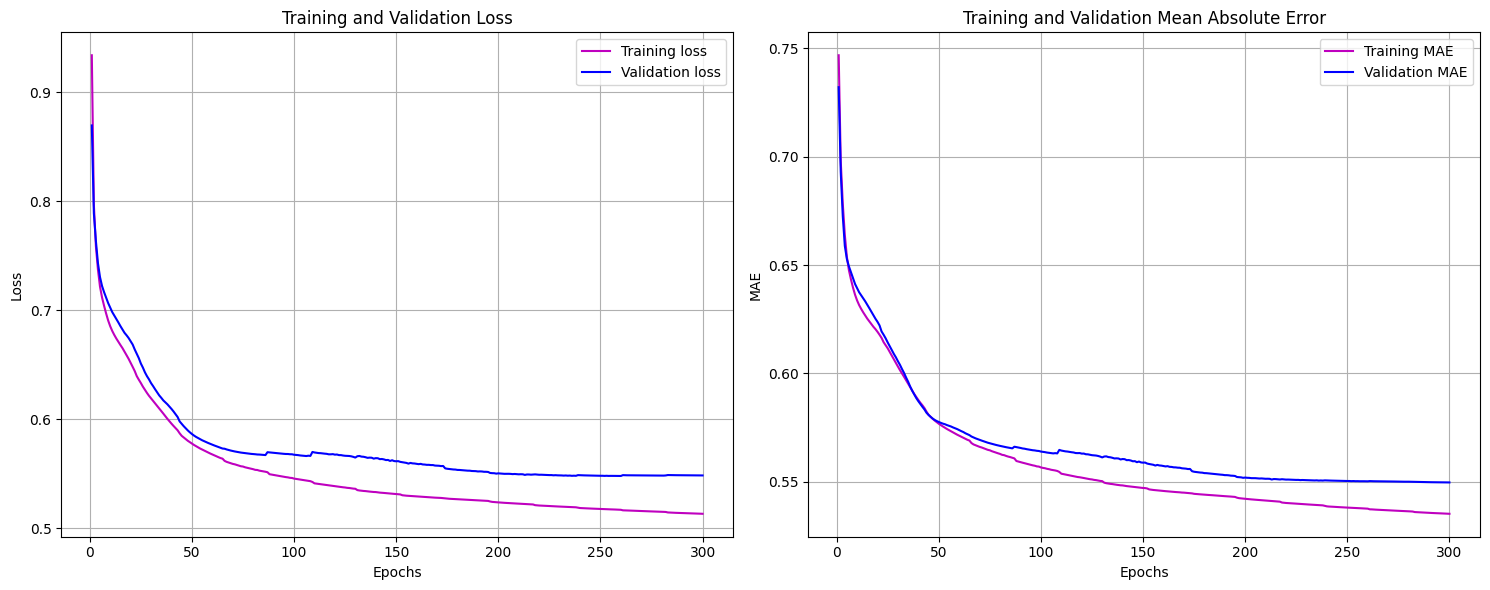

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract metrics from the history object
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(loss) + 1)

    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot training and validation loss
    axes[0].plot(epochs, loss, 'm', label='Training loss')
    axes[0].plot(epochs, val_loss, 'b', label='Validation loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Plot training and validation MAE
    axes[1].plot(epochs, mae, 'm', label='Training MAE')
    axes[1].plot(epochs, val_mae, 'b', label='Validation MAE')
    axes[1].set_title('Training and Validation Mean Absolute Error')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

# Call the function to plot the history
plot_training_history(history)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Scale the test set inputs using the scalers fitted on the full dataset
#t_test_scaled = time_var_scaler.transform(t_test)


# Make predictions on the scaled test inputs
predictions_scaled = model.predict((test_dataset))

# Inverse transform to get predictions and actuals back to original physical units
predictions = targets_scaler.inverse_transform(predictions_scaled)
Y_test_actual = targets_scaler.inverse_transform(y_test)

# Calculate final baseline metrics
rmse = np.sqrt(mean_squared_error(Y_test_actual, predictions))
r2 = r2_score(Y_test_actual, predictions)
mae = mean_absolute_error(Y_test_actual, predictions)

print(f"\n--- Evaluation Metrics ---")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R-squared: {r2:.4f}")
print(f"Test MAE: {mae:.4f}")

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- Evaluation Metrics ---
Test RMSE: 46.8007
Test R-squared: 0.4172
Test MAE: 24.9352


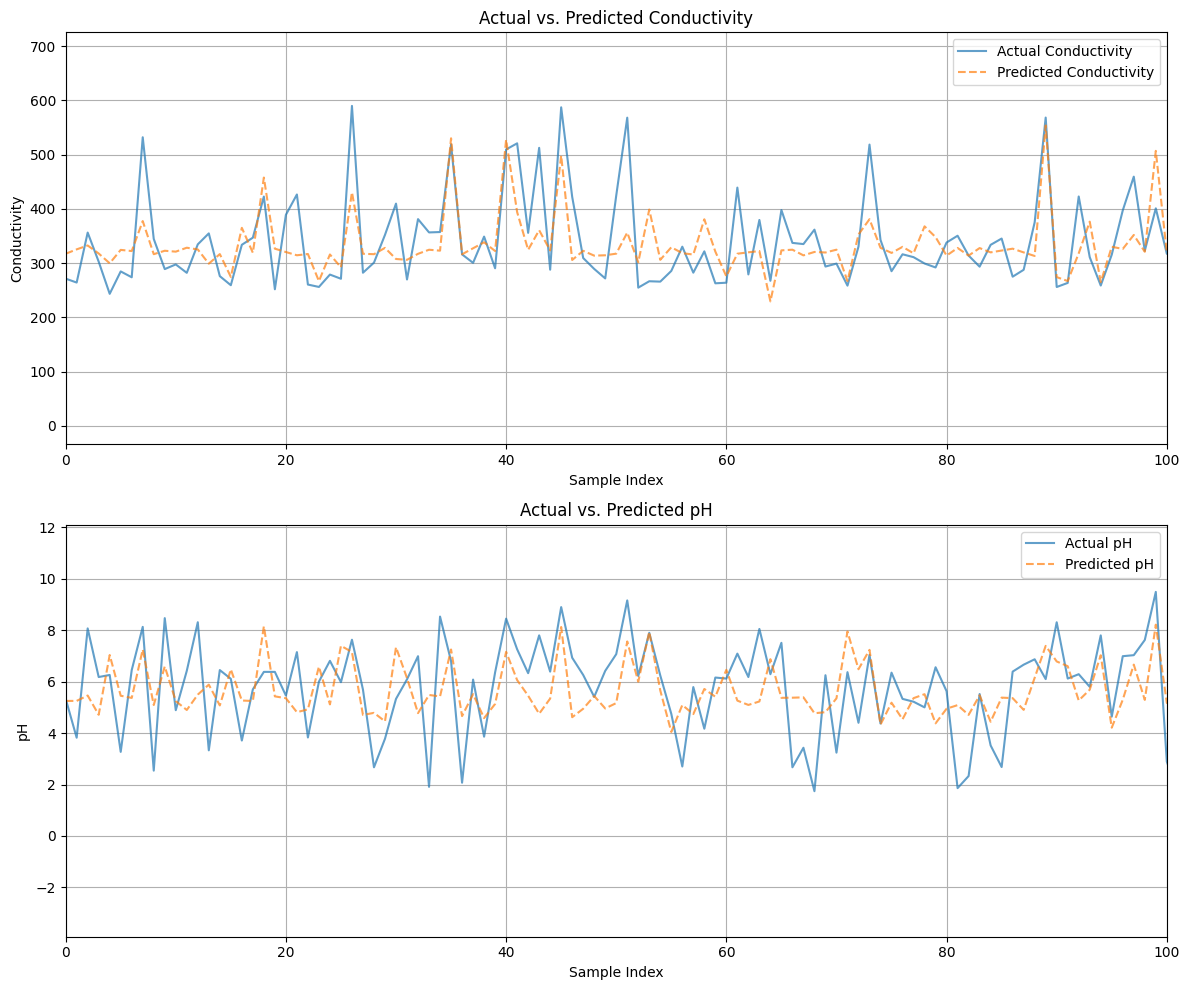

In [ ]:
import matplotlib.pyplot as plt

# Create a 2x1 figure for the plots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot for the first target (Conductivity)
axes[0].plot(Y_test_actual[:, 0], label='Actual Conductivity', alpha=0.7)
axes[0].plot(predictions[:, 0], label='Predicted Conductivity', alpha=0.7, linestyle='--')
axes[0].set_title('Actual vs. Predicted Conductivity')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Conductivity')
axes[0].legend()
axes[0].grid(True)
axes[0].set_xlim(0, 100) # Zoom in on x-axis

# Plot for the second target (pH)
axes[1].plot(Y_test_actual[:, 1], label='Actual pH', alpha=0.7)
axes[1].plot(predictions[:, 1], label='Predicted pH', alpha=0.7, linestyle='--')
axes[1].set_title('Actual vs. Predicted pH')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('pH')
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlim(0, 100) # Zoom in on x-axis

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()